## ***Load the Dataset***




In [15]:
# Import necessary libraries
from scipy.io import arff
import pandas as pd

# List of ARFF file paths
file_paths = ['/content/1year.arff','/content/2year.arff','/content/3year.arff','/content/4year.arff','/content/5year.arff']

# Initialize an empty list to store dataframes
dfs = []

# Load each ARFF file and append the dataframe to the list
for file_path in file_paths:
    # Load the ARFF file
    data, meta = arff.loadarff(file_path) # loadarff expects a single file path

    # Convert the ARFF data into a Pandas DataFrame
    df = pd.DataFrame(data)

    # Decode byte strings (common in ARFF files) to regular strings if needed
    for col in df.select_dtypes(['object']).columns:
        df[col] = df[col].str.decode('utf-8')

    # Append the dataframe to the list
    dfs.append(df)

# Concatenate all dataframes into a single dataframe
df = pd.concat(dfs)

# Save the DataFrame as a CSV file if needed (optional)
df.to_csv('dataset.csv', index=False)
print("\nDataset saved as 'dataset.csv'")




Dataset saved as 'dataset.csv'


# ***Exploring and Summary of Data Set***

In [ ]:
# View the first few rows of the dataset
print("\nFirst few rows of the dataset:")
print(df.head())


First few rows of the dataset:
      Attr1    Attr2    Attr3   Attr4    Attr5    Attr6     Attr7    Attr8  \
0  0.200550  0.37951  0.39641  2.0472  32.3510  0.38825  0.249760  1.33050   
1  0.209120  0.49988  0.47225  1.9447  14.7860  0.00000  0.258340  0.99601   
2  0.248660  0.69592  0.26713  1.5548  -1.1523  0.00000  0.309060  0.43695   
3  0.081483  0.30734  0.45879  2.4928  51.9520  0.14988  0.092704  1.86610   
4  0.187320  0.61323  0.22960  1.4063  -7.3128  0.18732  0.187320  0.63070   

    Attr9   Attr10  ...    Attr56   Attr57   Attr58    Attr59  Attr60  Attr61  \
0  1.1389  0.50494  ...  0.121960  0.39718  0.87804  0.001924  8.4160  5.1372   
1  1.6996  0.49788  ...  0.121300  0.42002  0.85300  0.000000  4.1486  3.2732   
2  1.3090  0.30408  ...  0.241140  0.81774  0.76599  0.694840  4.9909  3.9510   
3  1.0571  0.57353  ...  0.054015  0.14207  0.94598  0.000000  4.5746  3.6147   
4  1.1559  0.38677  ...  0.134850  0.48431  0.86515  0.124440  6.3985  4.3158   

    Attr62  

In [16]:
# shape of the dataset (rows, columns)
df.shape

(43405, 65)

In [ ]:
# summary of each column
print("Dataset Overview:")
print(df.info())

Dataset Overview:
<class 'pandas.core.frame.DataFrame'>
Index: 43405 entries, 0 to 5909
Data columns (total 65 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Attr1   43397 non-null  float64
 1   Attr2   43397 non-null  float64
 2   Attr3   43397 non-null  float64
 3   Attr4   43271 non-null  float64
 4   Attr5   43316 non-null  float64
 5   Attr6   43397 non-null  float64
 6   Attr7   43397 non-null  float64
 7   Attr8   43311 non-null  float64
 8   Attr9   43396 non-null  float64
 9   Attr10  43397 non-null  float64
 10  Attr11  43361 non-null  float64
 11  Attr12  43271 non-null  float64
 12  Attr13  43278 non-null  float64
 13  Attr14  43397 non-null  float64
 14  Attr15  43369 non-null  float64
 15  Attr16  43310 non-null  float64
 16  Attr17  43311 non-null  float64
 17  Attr18  43397 non-null  float64
 18  Attr19  43277 non-null  float64
 19  Attr20  43278 non-null  float64
 20  Attr21  37551 non-null  float64
 21  Attr22  43397 non-null 

In [ ]:
df.dtypes

,0
Attr1,float64
Attr2,float64
Attr3,float64
Attr4,float64
Attr5,float64
...,...
Attr61,float64
Attr62,float64
Attr63,float64
Attr64,float64


In [3]:
# List of columns to convert to categorical
categorical_columns = ['class']

# Convert each specified column to categorical
for col in categorical_columns:
    df[col] = df[col].astype('category')

# Check the data types
print(df.dtypes)

Attr1      float64
Attr2      float64
Attr3      float64
Attr4      float64
Attr5      float64
            ...   
Attr61     float64
Attr62     float64
Attr63     float64
Attr64     float64
class     category
Length: 65, dtype: object


In [ ]:
# summary statistics
# Numerical Data:
Num = df.describe()
print(Num)

#categorical Data:
Cat = df.describe(include='category')
print(Cat)

              Attr1         Attr2         Attr3         Attr4         Attr5  \
count  43397.000000  43397.000000  43397.000000  43271.000000  4.331600e+04   
mean       0.035160      0.590212      0.114431      6.314702 -3.853466e+02   
std        2.994109      5.842748      5.439429    295.434425  6.124303e+04   
min     -463.890000   -430.870000   -479.960000     -0.403110 -1.190300e+07   
25%        0.003429      0.268980      0.021521      1.049500 -4.908000e+01   
50%        0.049660      0.471900      0.196610      1.569800 -1.034500e+00   
75%        0.129580      0.688320      0.403390      2.787450  5.063425e+01   
max       94.280000    480.960000     28.336000  53433.000000  1.250100e+06   

              Attr6         Attr7         Attr8         Attr9        Attr10  \
count  43397.000000  43397.000000  43311.000000  43396.000000  43397.000000   
mean      -0.056107      0.093478     12.640779      2.652166      0.626868   
std        7.201326      5.713075    505.894281    

In [ ]:
# Show details about unique values in categorical variable
for column in df.select_dtypes(include=['category']).columns:
    print(f"Column: {column}")
    print(f"Unique values: {df[column].unique()}")
    print(f"Value counts:\n{df[column].value_counts()}\n")

Column: class
Unique values: ['0', '1']
Categories (2, object): ['0', '1']
Value counts:
class
0    41314
1     2091
Name: count, dtype: int64



In [ ]:
import scipy.stats as stats
import numpy as np

# Select numerical columns
numerical_cols = df.select_dtypes(include=['int64','float64']).columns

# Calculate and print skewness for each numerical column
for col in numerical_cols:

    skewness = stats.skew(df[col], nan_policy='omit')
    print(f"Skewness of {col}: {skewness}")

Skewness of Attr1: -114.341158052123
Skewness of Attr2: 56.89507110792051
Skewness of Attr3: -81.87342339262297
Skewness of Attr4: 155.57682479824223
Skewness of Attr5: -171.769828910844
Skewness of Attr6: -29.365959857006683
Skewness of Attr7: 18.901864372691225
Skewness of Attr8: 77.36789897079416
Skewness of Attr9: 109.08747028765431
Skewness of Attr10: 48.87686044625466
Skewness of Attr11: 53.49273434918687
Skewness of Attr12: 54.904599064092366
Skewness of Attr13: 117.99900791343107
Skewness of Attr14: 18.901859305941844
Skewness of Attr15: 15.890411673636379
Skewness of Attr16: 57.083841644171315
Skewness of Attr17: 76.88764774260332
Skewness of Attr18: 18.74042517670499
Skewness of Attr19: 158.56048079712332
Skewness of Attr20: 207.90548090904173
Skewness of Attr21: 112.78175518718228
Skewness of Attr22: 58.24399186289683
Skewness of Attr23: 161.770766594348
Skewness of Attr24: 45.77184076746712
Skewness of Attr25: 61.634133567517466
Skewness of Attr26: 58.73515234918379
Skewnes

**All Numerical variables are highly skewed.**

# ***Preprocess the Data***

## **Handling missing values**

In [19]:
# Check for missing values in each column
df.isnull().sum()

,0
Attr1,0
Attr2,0
Attr3,0
Attr4,0
Attr5,0
...,...
Attr61,0
Attr62,0
Attr63,0
Attr64,0


In [20]:
# Handling missing values
# For numerical columns, fill with the median
numerical_cols = df.select_dtypes(include=['float64', 'int64']).columns
df[numerical_cols] = df[numerical_cols].fillna(df[numerical_cols].median())

# Verify that all missing values are handled
missing_summary_after = df.isnull().sum()
print("\nMissing values after handling:\n", missing_summary_after)

# Save the cleaned dataset
df.to_csv('cleaned_dataset.csv', index=False)
print("Cleaned dataset saved as 'cleaned_dataset.csv'")


Missing values after handling:
 Attr1     0
Attr2     0
Attr3     0
Attr4     0
Attr5     0
         ..
Attr61    0
Attr62    0
Attr63    0
Attr64    0
class     0
Length: 65, dtype: int64
Cleaned dataset saved as 'cleaned_dataset.csv'


## **Handling Duplicates Values**

In [21]:
# Check for duplicates across all columns
duplicate_rows = df[df.duplicated()]
print(f"\nDuplicate rows found: {len(duplicate_rows)}")

# Print a few duplicate rows
if not duplicate_rows.empty:
    print("\nExample duplicate rows:")
    print(duplicate_rows.head())

# Remove duplicate rows
df = df.drop_duplicates()

# Print the shape of the DataFrame before and after removing duplicates
print(f"\nShape before removing duplicates: {df.shape}")
print(f"Shape after removing duplicates: {df.shape}")



Duplicate rows found: 401

Example duplicate rows:
         Attr1     Attr2     Attr3    Attr4    Attr5     Attr6    Attr7  \
118   0.099179  0.580440  0.254700  1.43880 -10.6760  0.099179  0.12489   
357   0.151750  0.649510 -0.022479  0.96434 -35.9790  0.194040  0.18937   
558   0.081602  0.158440  0.165720  2.36900  -3.4458  0.137000  0.11212   
1113  0.108470  0.704280  0.277410  1.39390  13.1000  0.272830  0.13401   
1199  0.216060  0.071064  0.448490  7.31110  49.8240  0.515580  0.26765   

         Attr8   Attr9   Attr10  ...    Attr56   Attr57   Attr58    Attr59  \
118    0.72283  1.0865  0.41956  ...  0.079592  0.23639  0.92041  0.000000   
357    0.49455  1.1202  0.32121  ...  0.107330  0.47244  0.89267  0.059458   
558    5.31140  1.0312  0.84156  ...  0.268200  0.00000  0.77112  0.044433   
1113   0.41675  1.0244  0.29351  ...  0.023781  0.36956  0.97622  0.000000   
1199  13.01800  1.1431  0.92512  ...  0.125200  0.23355  0.87480  0.000000   

       Attr60  Attr61   Attr

## **Detecting and Handling Outliers**

In [22]:
import matplotlib.pyplot as plt

# Function to detect outliers using the IQR method
def detect_outliers_iqr(df, column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    # Detect outliers
    outliers = df[(df[column] < lower_bound) | (df[column] > upper_bound)]
    return outliers, lower_bound, upper_bound

# Function to remove outliers (without capping, removes rows)
def remove_outliers_iqr(df, column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    # Keep only rows where values are within the bounds
    df_cleaned = df[(df[column] >= lower_bound) & (df[column] <= upper_bound)]
    return df_cleaned


# Select all numerical columns
numerical_columns = df.select_dtypes(include=['float64', 'int64']).columns

# Create a copy of the original DataFrame to modify (new_df)
new_df = df.copy()

# Remove outliers for each numerical column and update new_df
for column in numerical_columns:
    new_df = remove_outliers_iqr(new_df, column)

# Print the shape of the original and new DataFrame
print(f"\nOriginal DataFrame shape: {df.shape}")
print(f"New DataFrame shape (without outliers): {new_df.shape}")
print("Outliers have been removed and new_df has been created.")


Original DataFrame shape: (43004, 65)
New DataFrame shape (without outliers): (2165, 65)
Outliers have been removed and new_df has been created.


**Removing Outliers caused to reduce substantial number of data rows**

## **Transform skewed features**

In [23]:
import numpy as np
import seaborn as sns
from scipy import stats

# Function to calculate skewness and plot distribution
def plot_skewness(df, numerical_columns):
    skewed_cols = df[numerical_columns].apply(lambda x: x.skew()).sort_values(ascending=False)
    return skewed_cols


# Function to apply log transformation to skewed features
def log_transform(df, column):
    df[column] = np.log1p(df[column])  # log1p(x) = log(x + 1), handles zero values as well

# Function to apply square root transformation to skewed features
def sqrt_transform(df, column):
    df[column] = np.sqrt(df[column])

# Function to apply Box-Cox transformation to skewed features
def boxcox_transform(df, column):
    df[column], _ = stats.boxcox(df[column] + 1)  # Adding 1 to avoid zero values

# Identify skewed columns (skewness threshold can be adjusted)
numerical_columns = new_df.select_dtypes(include=['float64', 'int64']).columns
skewed_cols = plot_skewness(new_df, numerical_columns)

# Apply transformation for skewed columns
for col, skew in skewed_cols.items():
    if skew > 1:  # You can adjust this threshold based on your preference
        print(f"Transforming {col} (Skewness: {skew:.2f})...")

        # Apply log transformation if skew > 1
        log_transform(new_df, col)


print("Skewed features have been transformed.")


Transforming Attr9 (Skewness: 1.56)...
Transforming Attr27 (Skewness: 1.53)...
Transforming Attr37 (Skewness: 1.48)...
Transforming Attr40 (Skewness: 1.44)...
Transforming Attr8 (Skewness: 1.37)...
Transforming Attr17 (Skewness: 1.29)...
Transforming Attr60 (Skewness: 1.13)...
Transforming Attr15 (Skewness: 1.12)...
Transforming Attr59 (Skewness: 1.05)...
Transforming Attr4 (Skewness: 1.01)...
Skewed features have been transformed.


/usr/local/lib/python3.10/dist-packages/pandas/core/arraylike.py:399: RuntimeWarning: invalid value encountered in log1p
  result = getattr(ufunc, method)(*inputs, **kwargs)


## *Encoding Categorical Variables*

**Categorical variable was already encoded.**

## ***Scaling Numerical Features***

In [24]:
from sklearn.preprocessing import StandardScaler

#  Identify numeric and categorical features
numeric_features = new_df.select_dtypes(include=['number']).columns
categorical_features = new_df.select_dtypes(exclude=['number']).columns

#  Create a StandardScaler object
scaler = StandardScaler()

# Fit and transform the numeric features ONLY
new_df[numeric_features] = scaler.fit_transform(new_df[numeric_features])

print(new_df.head())

        Attr1     Attr2     Attr3     Attr4     Attr5     Attr6     Attr7  \
62  -0.603766  1.558679 -1.683384 -1.201651 -1.025250 -1.634315 -0.403281   
66   0.203892  1.430228 -0.853919 -0.761742 -2.580338 -0.604660  0.308985   
89   0.920997  0.104989  0.077574  0.212489 -0.075422 -1.252331  1.492664   
91   1.504808 -0.149774 -1.613307 -1.388122 -1.482819  0.222498  1.052179   
115  1.961712  0.780102 -0.976383 -0.942543 -0.457275 -0.604660  1.441859   

        Attr8     Attr9    Attr10  ...    Attr56    Attr57    Attr58  \
62  -1.285256  1.135860 -1.407749  ...  0.056885 -0.252002  0.587418   
66  -1.195225  0.559006 -1.276997  ...  0.541019  0.874788 -0.212827   
89  -0.114480  0.525888  0.089877  ...  2.546958  0.692943 -1.315660   
91  -0.578770 -0.607209 -0.911535  ...  0.428111  2.184422 -0.642517   
115 -0.700850  0.501073 -0.606446  ...  0.232054  2.313049 -1.192013   

       Attr59    Attr60    Attr61    Attr62    Attr63    Attr64  class  
62  -1.248769  0.084534 -0.9934

# ***Exploratory Data Analysis (EDA)***

## **Visualizing Features and Their Distributions**

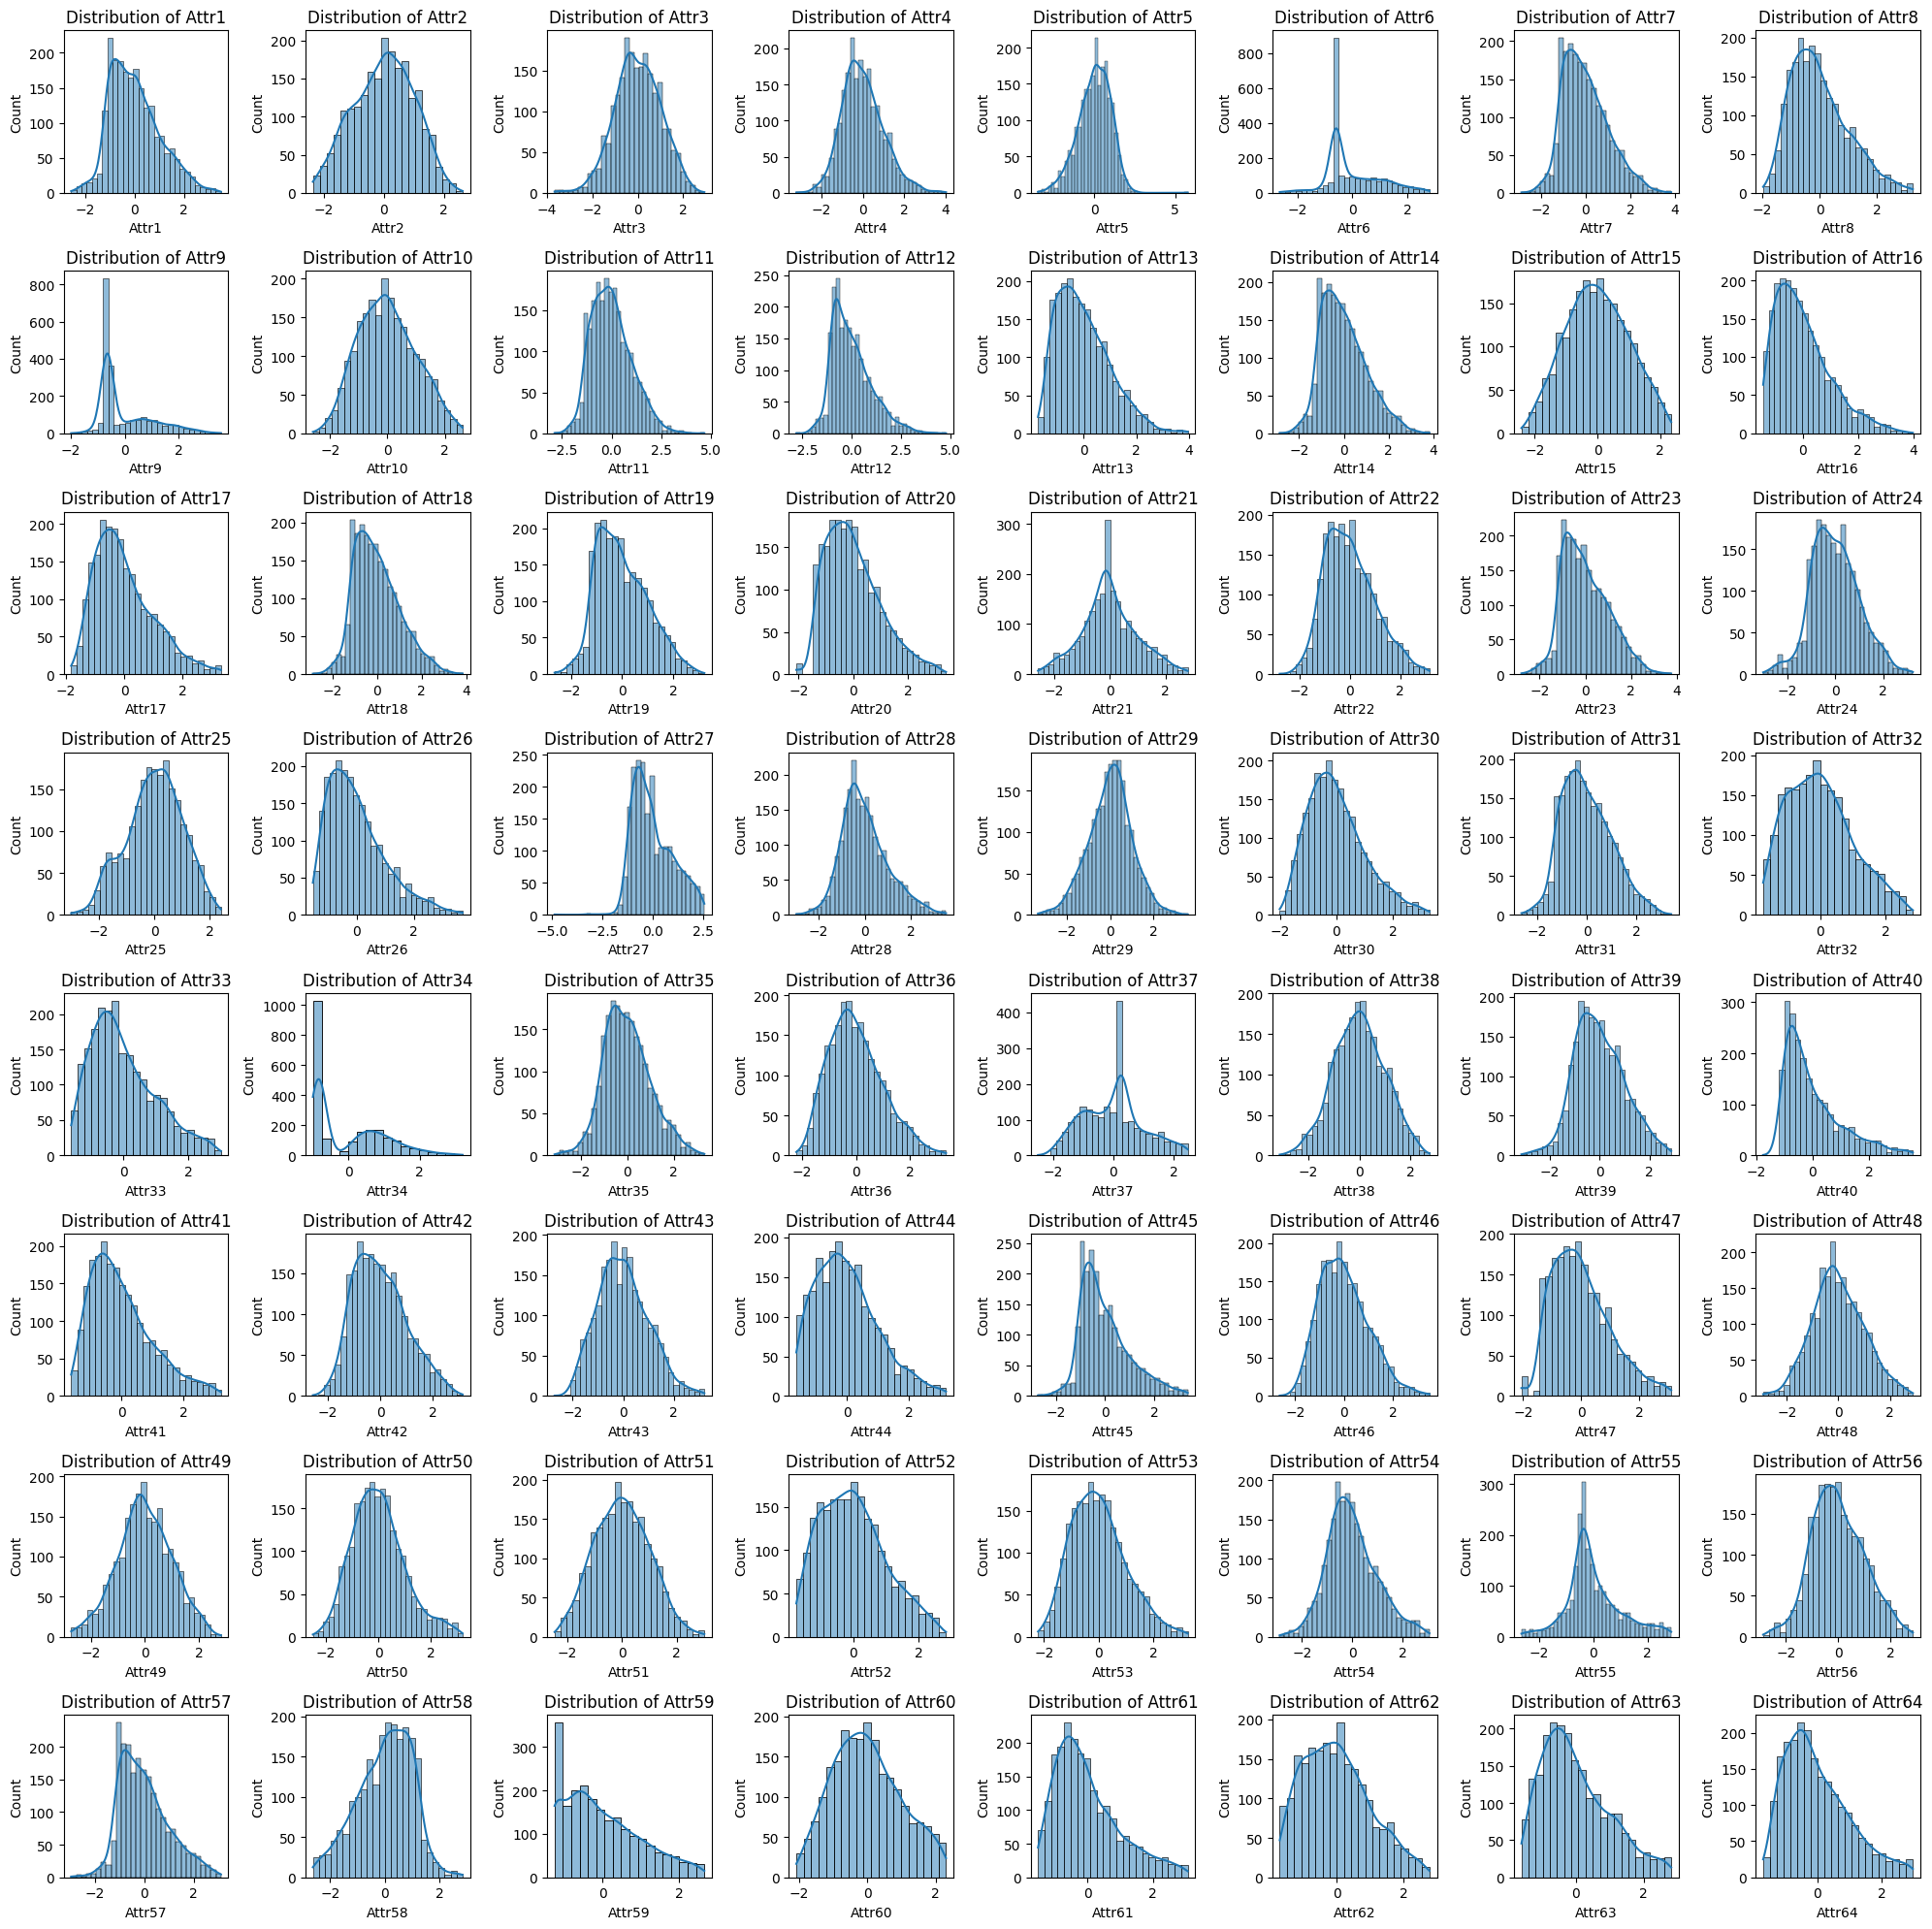

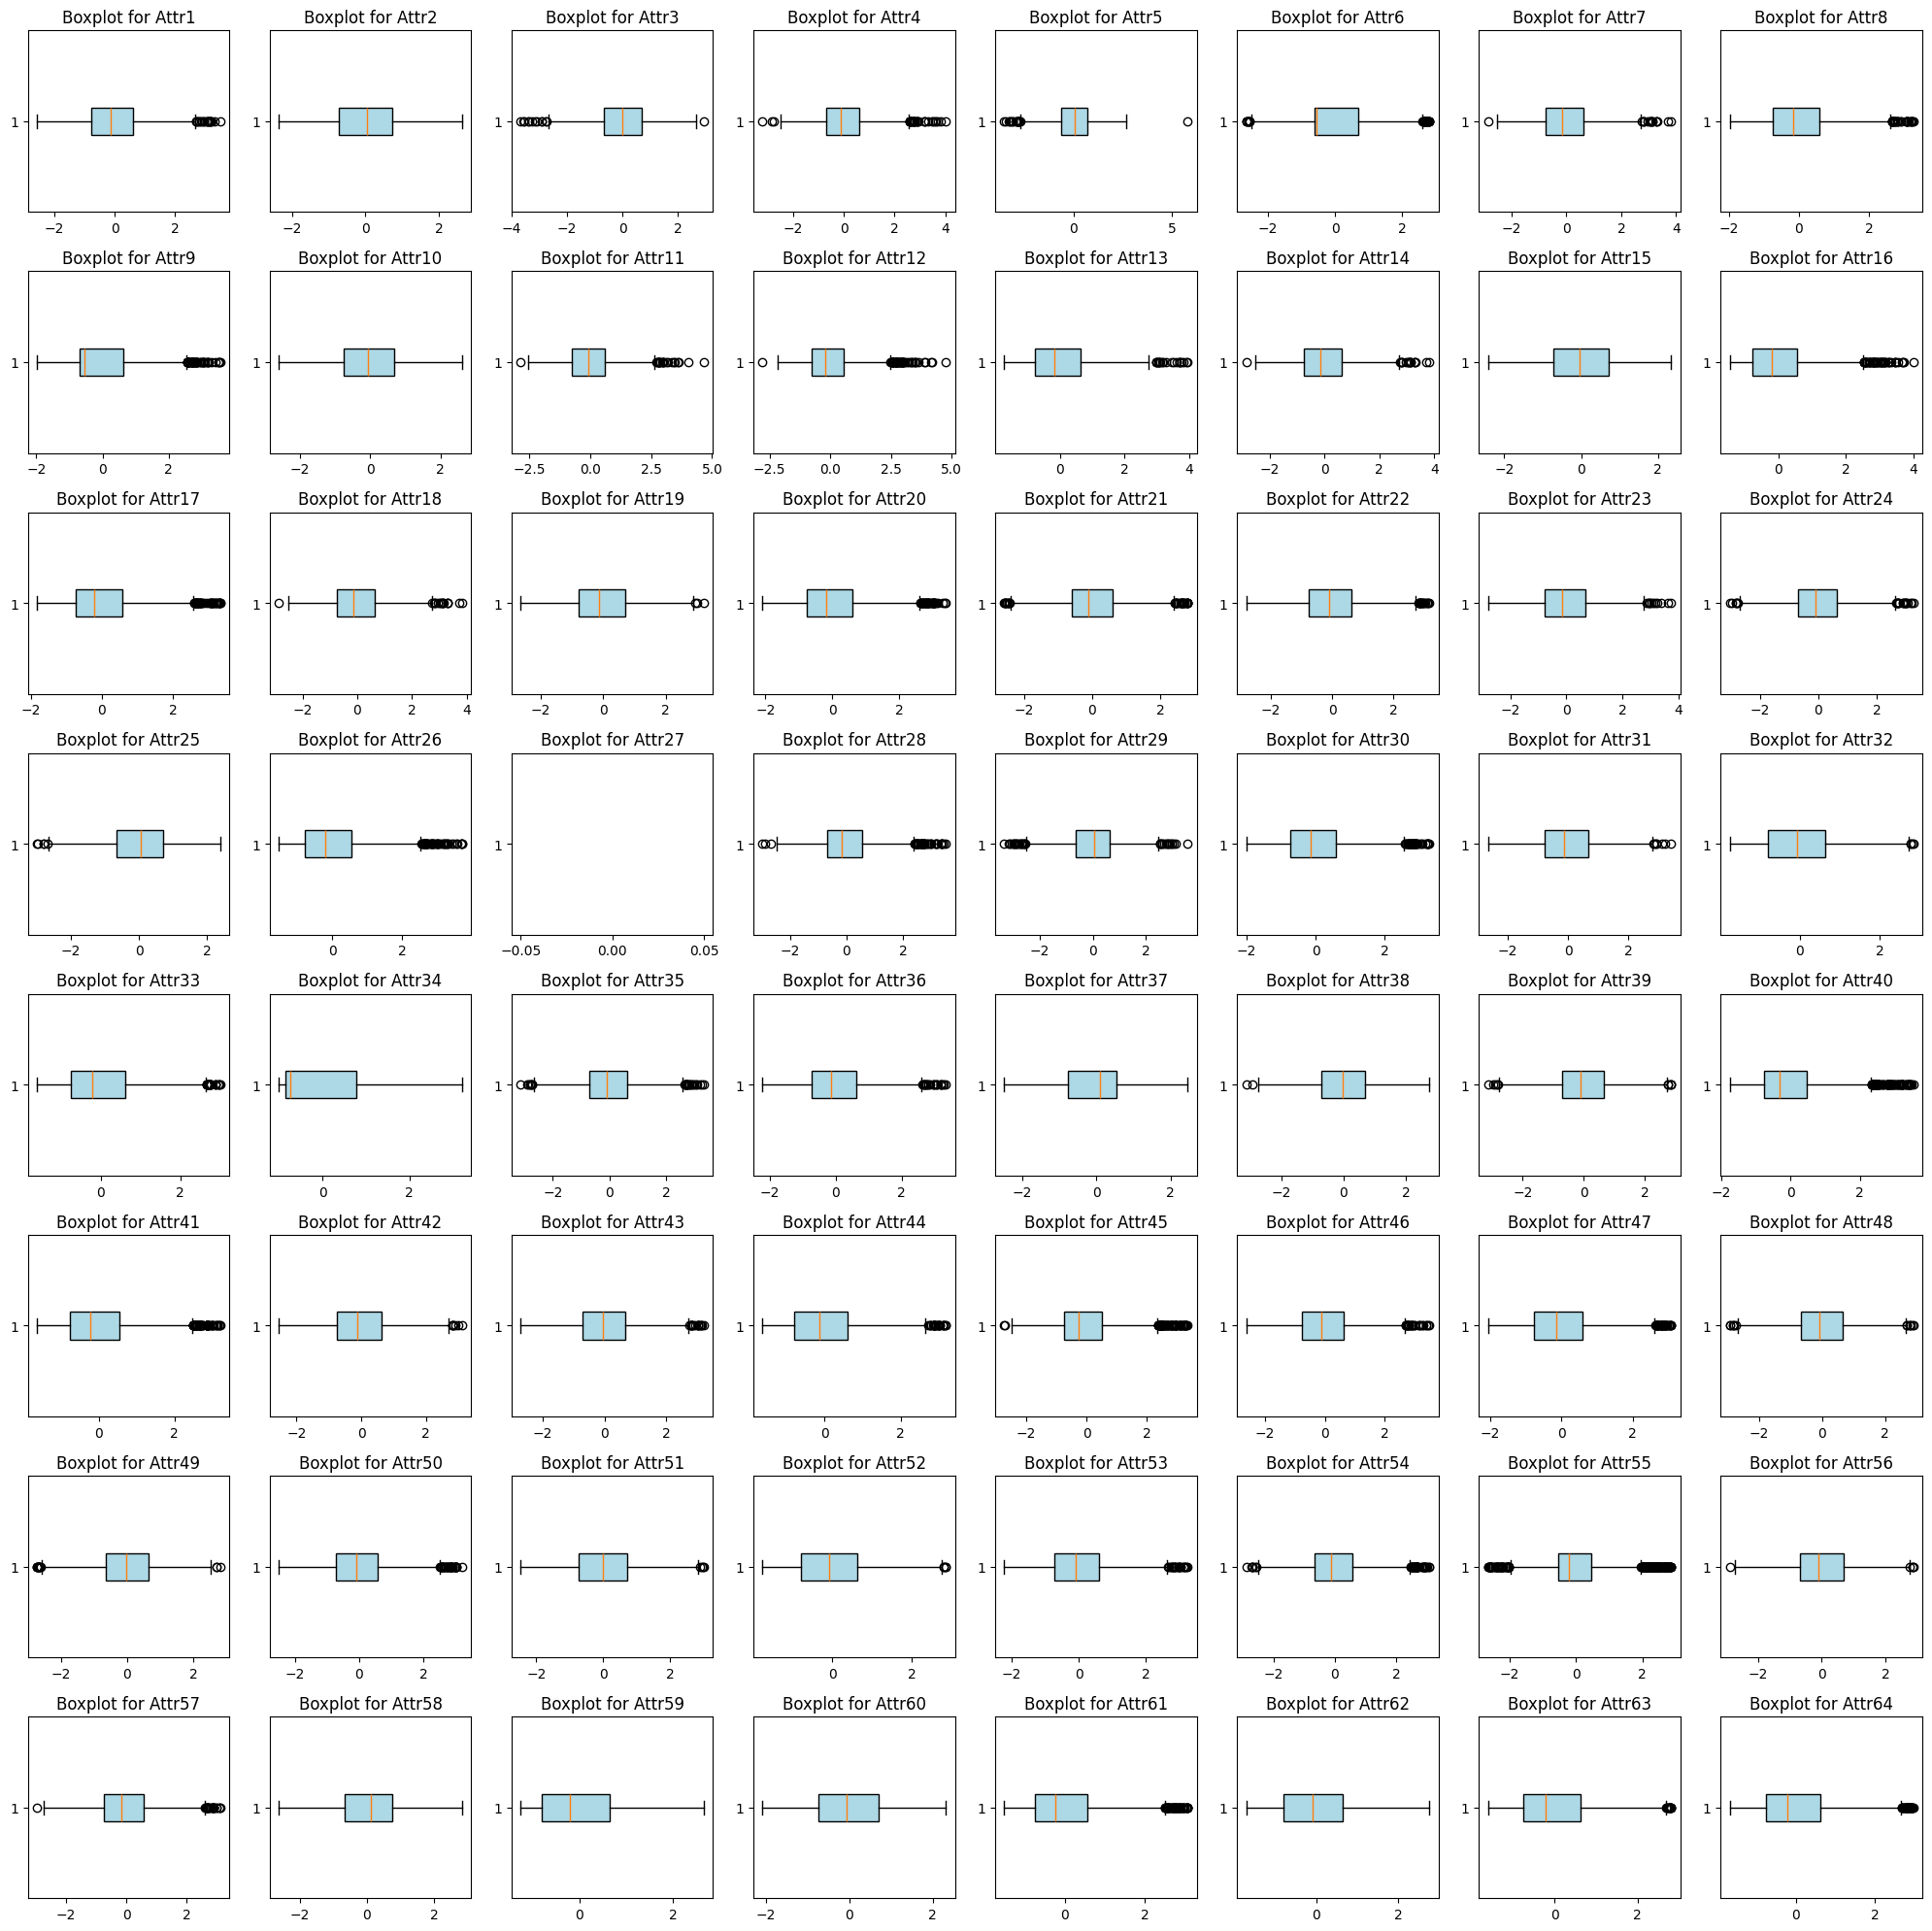

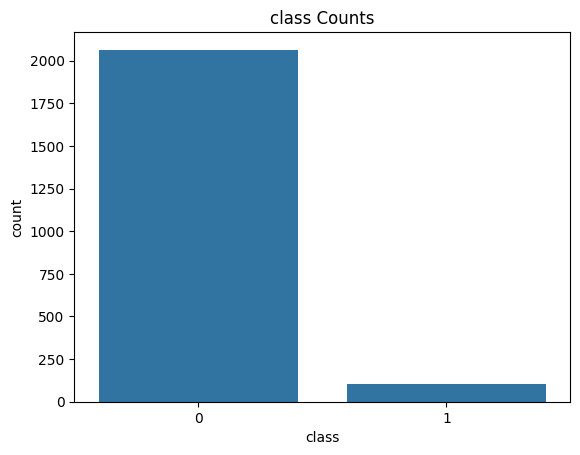

In [11]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# Histograms in an 8x8 grid
num_cols = new_df.select_dtypes(include=['number']).columns
num_plots = len(num_cols)
rows = 8
cols = 8

fig, axes = plt.subplots(rows, cols, figsize=(20, 20))  # Adjust figsize as needed
axes = axes.flatten()  # Flatten the axes array

for i, col in enumerate(num_cols):
    if i < rows * cols:  # Plot only if enough subplots are available
        sns.histplot(new_df[col], kde=True, ax=axes[i])
        axes[i].set_title(f'Distribution of {col}')

# Hide any unused subplots
for i in range(num_plots, rows * cols):
    axes[i].set_visible(False)

plt.tight_layout()  # Adjust spacing between subplots
plt.show()


# Box plots using matplotlib.pyplot.boxplot
num_cols = new_df.select_dtypes(include=['number']).columns
num_plots = len(num_cols)
rows = 8  # Number of rows in the grid
cols = 8  # Number of columns in the grid

fig, axes = plt.subplots(rows, cols, figsize=(20, 20))  # Adjust figsize as needed
axes = axes.flatten()  # Flatten the axes array

for i, col in enumerate(num_cols):
    if i < rows * cols:  # Plot only if enough subplots are available
        axes[i].boxplot(new_df[col], vert=False, patch_artist=True,
                        boxprops=dict(facecolor='lightblue'))
        axes[i].set_title(f'Boxplot for {col}')

# Hide any unused subplots
for i in range(num_plots, rows * cols):
    axes[i].set_visible(False)

plt.tight_layout()  # Adjust spacing between subplots
plt.show()



# Count plot for categorical feature (remains the same)
sns.countplot(x='class', data=new_df)
plt.title('class Counts')
plt.show()

## **Contingency Table**

In [106]:

# Contengency table - class counts
contingency_table = pd.crosstab(index=new_df['class'], columns='count')

print("Contingency Table for 'class':")
print(contingency_table)


Contingency Table for 'class':
col_0  count
class       
0       2064
1        101


In [107]:
overall_normalized = pd.crosstab(index=data['class'], columns='count', normalize='all')
print("Overall Normalized Contingency Table:")
print(overall_normalized)


Overall Normalized Contingency Table:
col_0     count
row_0          
b'0'   0.930626
b'1'   0.069374


## **Correlation Matrix**

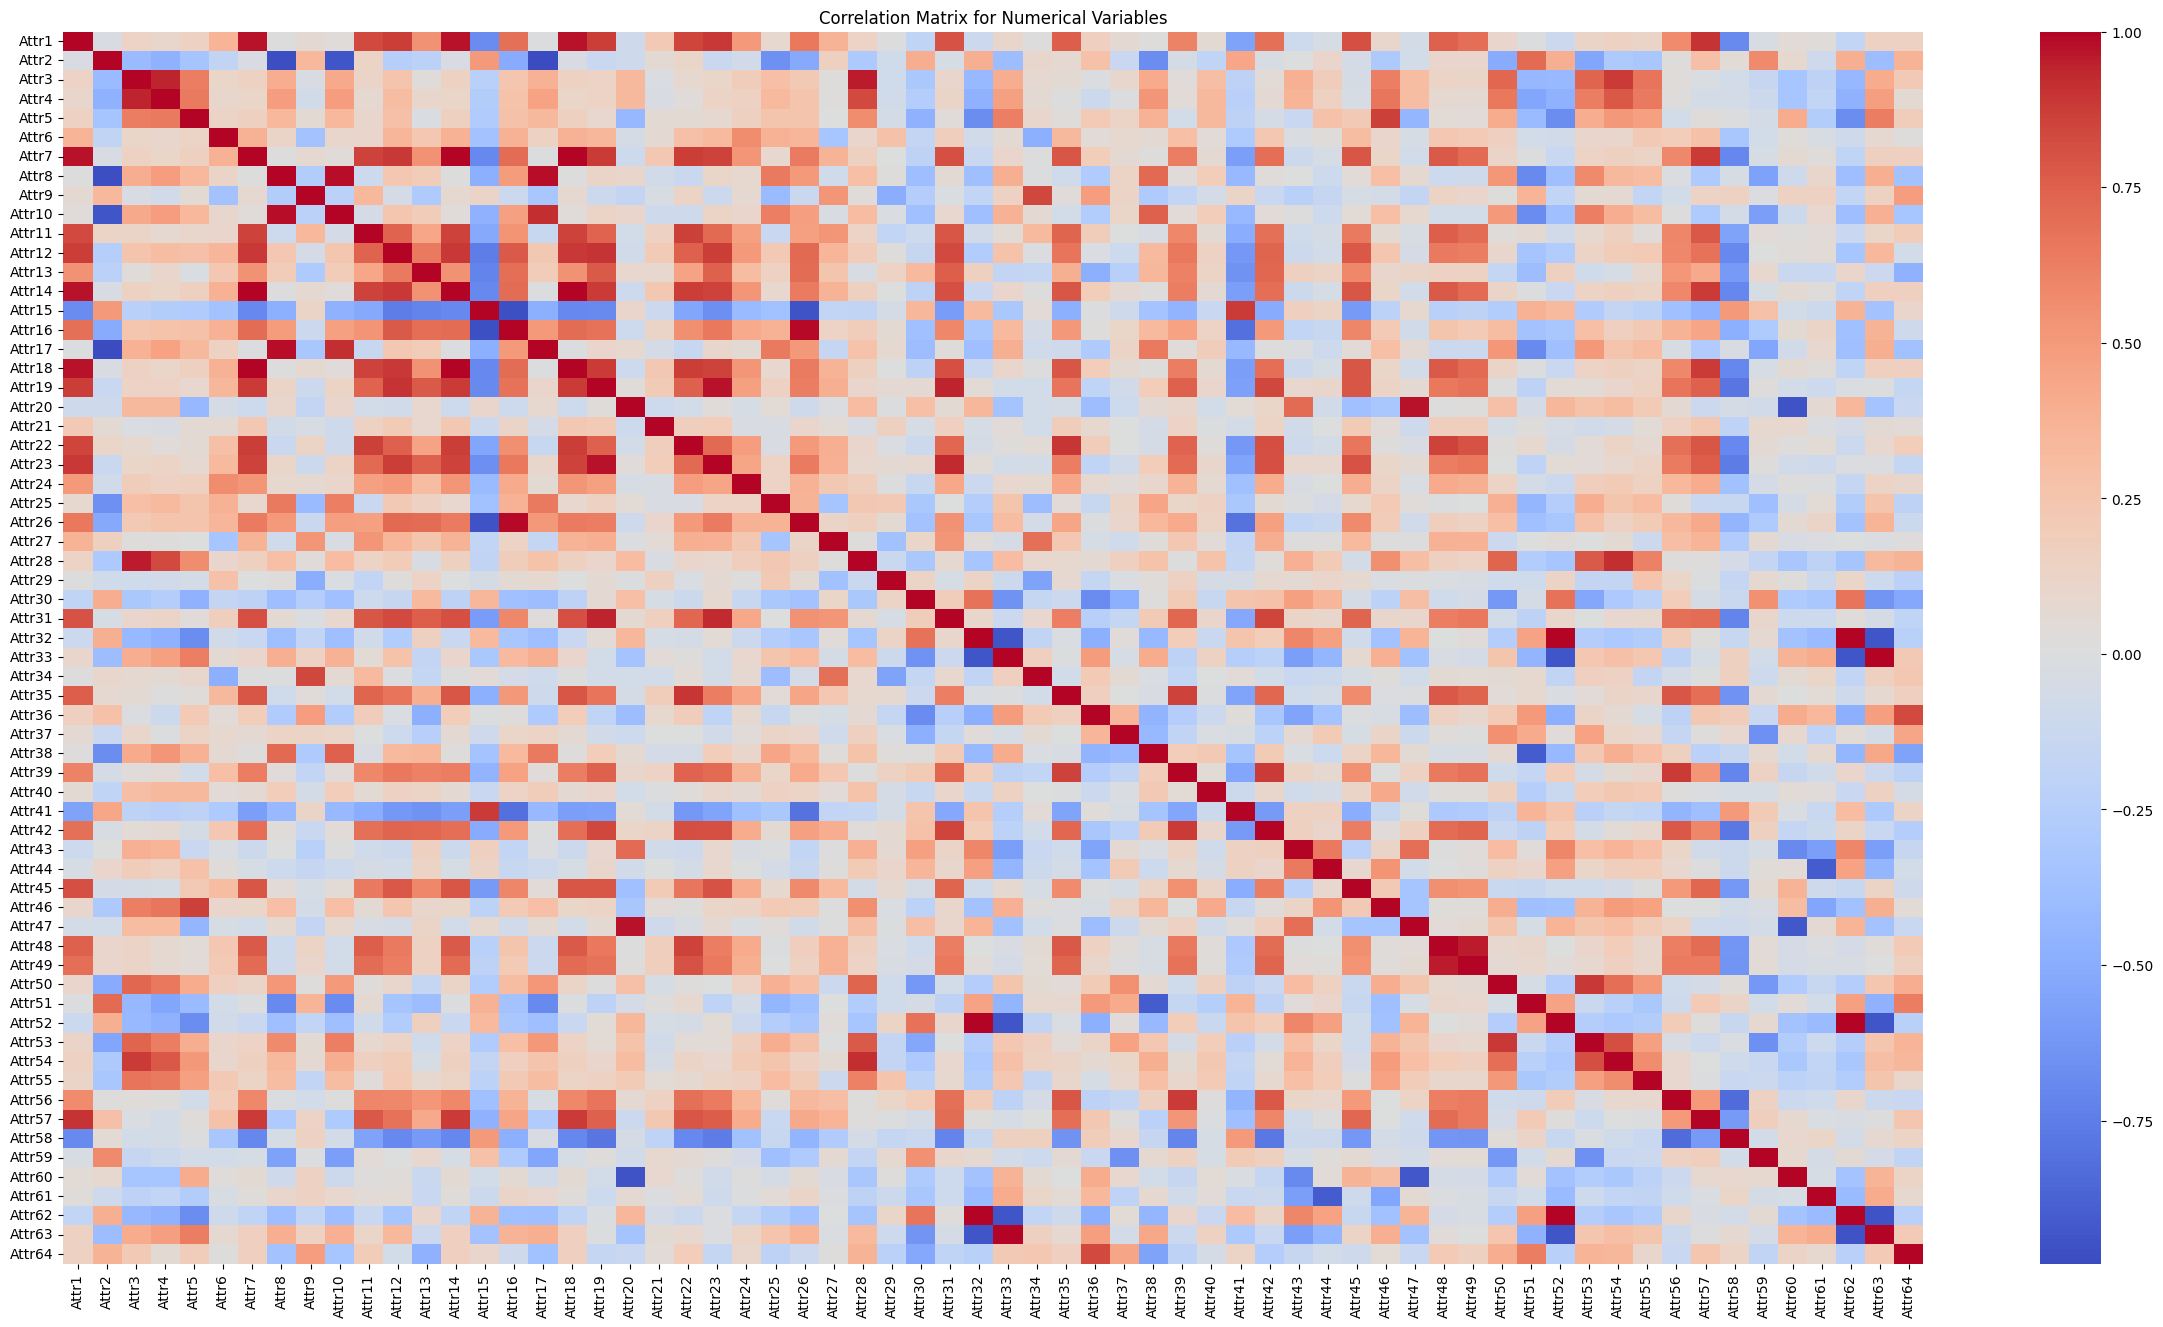

In [28]:
# Select only numerical columns
numerical_df = new_df.select_dtypes(include=['number'])

# Calculate the correlation matrix
correlation_matrix = numerical_df.corr()

# Create a heatmap for visualization
plt.figure(figsize=(20, 16))
sns.heatmap(correlation_matrix, annot=False, cmap='coolwarm', fmt=".2f",
             annot_kws={"size": 8})
plt.title('Correlation Matrix for Numerical Variables')
plt.show()

# **Data Preparation and Splitting**

## **Splitting**

In [50]:
# Import necessary libraries
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Split the data into features (X) and target (y)
X = new_df.drop(columns=['class'])  # Features (all columns except 'class')
y = new_df['class']  # Target variable (bankruptcy status)

# Normalize the features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Initial train-test split (70% training, 30% test)
X_train, X_temp, y_train, y_temp = train_test_split(
    X_scaled, y, test_size=0.3, random_state=42, stratify=y
)

# Split the temporary set into validation (15%) and evaluation (15%)
X_val, X_eval, y_val, y_eval = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp
)

# Check the sizes of each set
print("Training set:", X_train.shape, y_train.shape)
print("Validation set:", X_val.shape, y_val.shape)
print("Evaluation set:", X_eval.shape, y_eval.shape)

Training set: (1515, 64) (1515,)
Validation set: (325, 64) (325,)
Evaluation set: (325, 64) (325,)


## **Applying SMOTE for class balancing**

In [51]:
from imblearn.over_sampling import SMOTE

# Assuming X_train is a DataFrame
X_train = pd.DataFrame(X_train)
y_train = pd.Series(y_train)

# Check for missing values in X_train before dropping
missing_counts = X_train.isnull().sum().sum()
print(f"Number of missing values in X_train before dropping: {missing_counts}")

# Reset index of y_train to match X_train after dropping rows
y_train = y_train.reset_index(drop=True)

# Drop rows with missing values from X_train and update y_train accordingly
X_train = X_train.dropna()
y_train = y_train[X_train.index]

# Reset index of X_train to avoid potential issues
X_train = X_train.reset_index(drop=True)

# Apply SMOTE after handling missing values
smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

Number of missing values in X_train before dropping: 4


In [53]:
# Check class distribution before and after SMOTE
print("Class distribution before SMOTE:", Counter(y_train))
print("Class distribution after SMOTE:", Counter(y_train_smote))


Class distribution before SMOTE: Counter({'0': 1440, '1': 71})
Class distribution after SMOTE: Counter({'0': 1440, '1': 1440})


# ***Model Tranning & Evaluation***

## **Logistic Regression**

In [83]:
import pandas as pd
from sklearn.metrics import classification_report, accuracy_score, roc_auc_score, precision_score, recall_score, f1_score
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from xgboost import XGBClassifier
from sklearn.svm import SVC

# Dictionary to store the results of each model
model_results = {}

# Convert y_val to integers if it's not already
y_val = y_val.astype(int) # Convert y_val to integer labels before training models

# Logistic Regression
lr = LogisticRegression(random_state=42, max_iter=1000)
lr.fit(X_train_smote, y_train_smote)
y_val_pred_lr = lr.predict(X_val)

# Convert predictions to integers to match y_val type
y_val_pred_lr = y_val_pred_lr.astype(int) # This line ensures both are integers

y_val_proba_lr = lr.predict_proba(X_val)[:, 1]
accuracy_lr = accuracy_score(y_val, y_val_pred_lr)
roc_auc_lr = roc_auc_score(y_val, y_val_proba_lr)
precision_lr = precision_score(y_val, y_val_pred_lr)
recall_lr = recall_score(y_val, y_val_pred_lr)
f1_lr = f1_score(y_val, y_val_pred_lr)

# Save results for Logistic Regression
model_results['Logistic Regression'] = {
    "accuracy": accuracy_lr,
    "precision": precision_lr,
    "recall": recall_lr,
    "f1_score": f1_lr,
    "roc_auc": roc_auc_lr,
}


## **Decision Tree**

In [84]:
# Convert y_val to integers if it's not already
y_val = y_val.astype(int) # Convert y_val to integer labels before training models

# Decision Tree
dt = DecisionTreeClassifier(random_state=42)
dt.fit(X_train_smote, y_train_smote)
y_val_pred_dt = dt.predict(X_val)

# Convert predictions to integers to match y_val type
y_val_pred_dt = y_val_pred_dt.astype(int) # This line ensures both are integers
y_val_proba_dt = dt.predict_proba(X_val)[:, 1]

#Results
accuracy_dt = accuracy_score(y_val, y_val_pred_dt)
roc_auc_dt = roc_auc_score(y_val, y_val_proba_dt)
precision_dt = precision_score(y_val, y_val_pred_dt)
recall_dt = recall_score(y_val, y_val_pred_dt)
f1_dt = f1_score(y_val, y_val_pred_dt)

# Save results for Decision Tree
model_results['Decision Tree'] = {
    "accuracy": accuracy_dt,
    "precision": precision_dt,
    "recall": recall_dt,
    "f1_score": f1_dt,
    "roc_auc": roc_auc_dt,
}

## **Random Forest**

In [86]:
# Convert y_val to integers if it's not already
y_val = y_val.astype(int) # Convert y_val to integer labels before training models

# Random Forest
rf = RandomForestClassifier(random_state=42)
rf.fit(X_train_smote, y_train_smote)
y_val_pred_rf = rf.predict(X_val)

# Convert predictions to integers to match y_val type
y_val_pred_rf = y_val_pred_rf.astype(int) # This line ensures both are integers
y_val_proba_rf = rf.predict_proba(X_val)[:, 1]

# Results
accuracy_rf = accuracy_score(y_val, y_val_pred_rf)
roc_auc_rf = roc_auc_score(y_val, y_val_proba_rf)
precision_rf = precision_score(y_val, y_val_pred_rf)
recall_rf = recall_score(y_val, y_val_pred_rf)
f1_rf = f1_score(y_val, y_val_pred_rf)

# Save results for Random Forest
model_results['Random Forest'] = {
    "accuracy": accuracy_rf,
    "precision": precision_rf,
    "recall": recall_rf,
    "f1_score": f1_rf,
    "roc_auc": roc_auc_rf,
}


## **Gradient Boosting (XGBoost)**

In [87]:
# Convert y_val to integers if it's not already
y_val = y_val.astype(int) # Convert y_val to integer labels before training models

# Convert y_train_smote to integers if it's not already
y_train_smote = y_train_smote.astype(int) # This converts '0' and '1' to 0 and 1

# XGBoost
xgb = XGBClassifier(random_state=42)
xgb.fit(X_train_smote, y_train_smote)
y_val_pred_xgb = xgb.predict(X_val)

# Convert predictions to integers to match y_val type
y_val_pred_rf = y_val_pred_rf.astype(int) # This line ensures both are integers
y_val_proba_xgb = xgb.predict_proba(X_val)[:, 1]

#Results
accuracy_xgb = accuracy_score(y_val, y_val_pred_xgb)
roc_auc_xgb = roc_auc_score(y_val, y_val_proba_xgb)
precision_xgb = precision_score(y_val, y_val_pred_xgb)
recall_xgb = recall_score(y_val, y_val_pred_xgb)
f1_xgb = f1_score(y_val, y_val_pred_xgb)

# Save results for XGBoost
model_results['XGBoost'] = {
    "accuracy": accuracy_xgb,
    "precision": precision_xgb,
    "recall": recall_xgb,
    "f1_score": f1_xgb,
    "roc_auc": roc_auc_xgb,
}

## ***Results of models***

In [88]:
# Convert the results to a pandas DataFrame for easier comparison
results_df = pd.DataFrame(model_results).T
print("\nModel Comparison Results:")
print(results_df)


Model Comparison Results:
                     accuracy  precision    recall  f1_score   roc_auc
Logistic Regression  0.858462   0.196078  0.666667  0.303030  0.827097
Decision Tree        0.932308   0.360000  0.600000  0.450000  0.774194
Random Forest        0.975385   0.818182  0.600000  0.692308  0.974731
XGBoost              0.972308   0.687500  0.733333  0.709677  0.983226


# ***Hyperparameter tuning***


> Used Randomized search for efficiency



## **Logistic Regression**

In [70]:
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import randint, uniform

#  Logistic Regression Hyperparameter Tuning with RandomizedSearchCV

param_dist_lr = {
    'C': uniform(0.01, 10),  # Regularization strength, uniform distribution
    'solver': ['liblinear', 'saga'],  # Solver algorithms
    'max_iter': randint(1000, 5000)  # Random number of iterations between 1000 and 5000
}

lr = LogisticRegression(random_state=42)

random_search_lr = RandomizedSearchCV(lr, param_distributions=param_dist_lr,
                                      n_iter=100, cv=5, n_jobs=-1, scoring='roc_auc', random_state=42)

random_search_lr.fit(X_train_smote, y_train_smote)

best_params_lr = random_search_lr.best_params_
best_score_lr = random_search_lr.best_score_

print(f"Best Hyperparameters for Logistic Regression: {best_params_lr}")
print(f"Best ROC-AUC Score for Logistic Regression: {best_score_lr}")


Tuning Hyperparameters for Logistic Regression...
Best Hyperparameters for Logistic Regression: {'C': 9.987404850489419, 'max_iter': 1698, 'solver': 'liblinear'}
Best ROC-AUC Score for Logistic Regression: 0.9675757137345681


## **Decision Tree**

In [71]:
#  Decision Tree Hyperparameter Tuning with RandomizedSearchCV

param_dist_dt = {
    'max_depth': [None, 10, 20, 30, 40],
    'min_samples_split': randint(2, 20),
    'min_samples_leaf': randint(1, 20),
    'criterion': ['gini', 'entropy']
}

dt = DecisionTreeClassifier(random_state=42)

random_search_dt = RandomizedSearchCV(dt, param_distributions=param_dist_dt,
                                      n_iter=100, cv=5, n_jobs=-1, scoring='roc_auc', random_state=42)

random_search_dt.fit(X_train_smote, y_train_smote)

best_params_dt = random_search_dt.best_params_
best_score_dt = random_search_dt.best_score_

print(f"Best Hyperparameters for Decision Tree: {best_params_dt}")
print(f"Best ROC-AUC Score for Decision Tree: {best_score_dt}")


Best Hyperparameters for Decision Tree: {'criterion': 'entropy', 'max_depth': 30, 'min_samples_leaf': 14, 'min_samples_split': 17}
Best ROC-AUC Score for Decision Tree: 0.9796440972222223


## **Random Forest**

In [72]:
# Random Forest Hyperparameter Tuning with RandomizedSearchCV

param_dist_rf = {
    'n_estimators': randint(50, 300),  # Random number of trees between 50 and 300
    'max_depth': [None, 10, 20, 30, 40],
    'min_samples_split': randint(2, 20),
    'min_samples_leaf': randint(1, 20),
    'bootstrap': [True, False]
}

rf = RandomForestClassifier(random_state=42)

random_search_rf = RandomizedSearchCV(rf, param_distributions=param_dist_rf,
                                      n_iter=100, cv=5, n_jobs=-1, scoring='roc_auc', random_state=42)

random_search_rf.fit(X_train_smote, y_train_smote)

best_params_rf = random_search_rf.best_params_
best_score_rf = random_search_rf.best_score_

print(f"Best Hyperparameters for Random Forest: {best_params_rf}")
print(f"Best ROC-AUC Score for Random Forest: {best_score_rf}")

Best Hyperparameters for Random Forest: {'bootstrap': False, 'max_depth': 40, 'min_samples_leaf': 4, 'min_samples_split': 6, 'n_estimators': 200}
Best ROC-AUC Score for Random Forest: 0.9998022762345679


## **Gradient Boosting (XGBoost)**

In [73]:
# XGBoost Hyperparameter Tuning with RandomizedSearchCV


param_dist_xgb = {
    'n_estimators': randint(50, 300),
    'learning_rate': uniform(0.01, 0.2),  # Random float between 0.01 and 0.2
    'max_depth': randint(3, 10),
    'subsample': uniform(0.7, 0.3),
    'colsample_bytree': uniform(0.7, 0.3)
}

xgb = XGBClassifier(random_state=42)

random_search_xgb = RandomizedSearchCV(xgb, param_distributions=param_dist_xgb,
                                       n_iter=100, cv=5, n_jobs=-1, scoring='roc_auc', random_state=42)

random_search_xgb.fit(X_train_smote, y_train_smote)

best_params_xgb = random_search_xgb.best_params_
best_score_xgb = random_search_xgb.best_score_

print(f"Best Hyperparameters for XGBoost: {best_params_xgb}")
print(f"Best ROC-AUC Score for XGBoost: {best_score_xgb}")

Best Hyperparameters for XGBoost: {'colsample_bytree': 0.7782083584707709, 'learning_rate': 0.10920749085868124, 'max_depth': 4, 'n_estimators': 294, 'subsample': 0.8045009813359592}
Best ROC-AUC Score for XGBoost: 0.9997998649691358


In [82]:
print(model_results)

{'Logistic Regression': {'accuracy': 0.8584615384615385, 'precision': 0.19607843137254902, 'recall': 0.6666666666666666, 'f1_score': 0.30303030303030304, 'roc_auc': 0.8270967741935484}}


# ***Retraining models with best hyper-parameters***

## **Retraining**

In [93]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
)

# Ensure target values are integers
y_train_smote = y_train_smote.astype(int)
y_val = y_val.astype(int)
y_test = y_test.astype(int)

# Dictionary to store retrained model results
retrained_results = {}

# Retraining and evaluating models
def retrain_and_evaluate(model, model_name, X_train, y_train, X_val, y_val, results_dict):
    """
    Retrain the model using the best hyperparameters, evaluate on validation data, and save metrics.
    """
    # Train the model
    model.fit(X_train, y_train)

    # Predictions and probabilities
    y_val_pred = model.predict(X_val).astype(int)  # Ensure predictions are integers
    y_val_proba = model.predict_proba(X_val)[:, 1]  # Positive class probabilities

    # Calculate metrics
    accuracy = accuracy_score(y_val, y_val_pred)
    precision = precision_score(y_val, y_val_pred)
    recall = recall_score(y_val, y_val_pred)
    f1 = f1_score(y_val, y_val_pred)
    roc_auc = roc_auc_score(y_val, y_val_proba)
    pr_auc = average_precision_score(y_val, y_val_proba)

    # Save results
    results_dict[model_name] = {
        "accuracy": accuracy,
        "precision": precision,
        "recall": recall,
        "f1_score": f1,
        "roc_auc": roc_auc,
    }



# Random Forest (with best hyperparameters)
rf_final = RandomForestClassifier(**best_params_rf, random_state=42)
retrain_and_evaluate(rf_final, "Random Forest", X_train_smote, y_train_smote, X_val, y_val, retrained_results)

# Decision Tree (with best hyperparameters)
dt_final = DecisionTreeClassifier(**best_params_dt, random_state=42)
retrain_and_evaluate(dt_final, "Decision Tree", X_train_smote, y_train_smote, X_val, y_val, retrained_results)

# XGBoost (with best hyperparameters)
xgb_final = XGBClassifier(**best_params_xgb, random_state=42)
retrain_and_evaluate(xgb_final, "XGBoost", X_train_smote, y_train_smote, X_val, y_val, retrained_results)

# Logistic Regression (with best hyperparameters)
lr_final = LogisticRegression(**best_params_lr, random_state=42)
retrain_and_evaluate(lr_final, "Logistic Regression", X_train_smote, y_train_smote, X_val, y_val, retrained_results)


## **Comparing Results**

In [94]:
# Convert results to DataFrames
initial_results_df = pd.DataFrame(model_results).T  # Transpose for easier viewing
retrained_results_df = pd.DataFrame(retrained_results).T

# Merge results for comparison
comparison_df = pd.concat([initial_results_df, retrained_results_df], axis=1, keys=["Initial", "Retrained"])

# Display comparison table
print(comparison_df)


                      Initial                                          \
                     accuracy precision    recall  f1_score   roc_auc   
Logistic Regression  0.858462  0.196078  0.666667  0.303030  0.827097   
Decision Tree        0.932308  0.360000  0.600000  0.450000  0.774194   
Random Forest        0.975385  0.818182  0.600000  0.692308  0.974731   
XGBoost              0.972308  0.687500  0.733333  0.709677  0.983226   

                    Retrained                                          
                     accuracy precision    recall  f1_score   roc_auc  
Logistic Regression  0.855385  0.166667  0.533333  0.253968  0.810753  
Decision Tree        0.923077  0.343750  0.733333  0.468085  0.826667  
Random Forest        0.969231  0.727273  0.533333  0.615385  0.976129  
XGBoost              0.975385  0.733333  0.733333  0.733333  0.985376  


# ***Final Evaluation with Evaluation set***

## **Evaluation**

In [125]:
# Ensure y_eval is integers
y_eval = y_eval.astype(int)

# Dictionary to store final evaluation results
evaluation_results = {}

# Function to evaluate a model on the evaluation set
def evaluate_on_eval_set(model, model_name, X_eval, y_eval, results_dict):
    """
    Evaluate a trained model on the evaluation set and save metrics.
    """
    # Predictions and probabilities
    y_eval_pred = model.predict(X_eval).astype(int)  # Ensure predictions are integers
    y_eval_proba = model.predict_proba(X_eval)[:, 1]  # Positive class probabilities

    # Calculate metrics
    accuracy = accuracy_score(y_eval, y_eval_pred)
    precision = precision_score(y_eval, y_eval_pred)
    recall = recall_score(y_eval, y_eval_pred)
    f1 = f1_score(y_eval, y_eval_pred)
    roc_auc = roc_auc_score(y_eval, y_eval_proba)


    # Save results
    results_dict[model_name] = {
        "accuracy": accuracy,
        "precision": precision,
        "recall": recall,
        "f1_score": f1,
        "roc_auc": roc_auc,
    }



# Evaluate each model
evaluate_on_eval_set(rf_final, "Random Forest", X_eval, y_eval, evaluation_results)
evaluate_on_eval_set(dt_final, "Decision Tree", X_eval, y_eval, evaluation_results)
evaluate_on_eval_set(xgb_final, "XGBoost", X_eval, y_eval, evaluation_results)
evaluate_on_eval_set(lr_final, "Logistic Regression", X_eval, y_eval, evaluation_results)



## **Comparison**

In [126]:
# Convert all results to DataFrames
initial_results_df = pd.DataFrame(model_results).T  # From initial training
retrained_results_df = pd.DataFrame(retrained_results).T  # From retraining
evaluation_results_df = pd.DataFrame(evaluation_results).T  # From final evaluation

# Merge results into a single comparison DataFrame
comparison_df = pd.concat(
    [initial_results_df, retrained_results_df, evaluation_results_df],
    axis=1,
    keys=["Initial", "Retrained", "Final Evaluation"]
)

# Display comparison table
print(comparison_df)


                      Initial                                          \
                     accuracy precision    recall  f1_score   roc_auc   
Logistic Regression  0.858462  0.196078  0.666667  0.303030  0.827097   
Decision Tree        0.932308  0.360000  0.600000  0.450000  0.774194   
Random Forest        0.975385  0.818182  0.600000  0.692308  0.974731   
XGBoost              0.972308  0.687500  0.733333  0.709677  0.983226   

                    Retrained                                          \
                     accuracy precision    recall  f1_score   roc_auc   
Logistic Regression  0.855385  0.166667  0.533333  0.253968  0.810753   
Decision Tree        0.923077  0.343750  0.733333  0.468085  0.826667   
Random Forest        0.969231  0.727273  0.533333  0.615385  0.976129   
XGBoost              0.975385  0.733333  0.733333  0.733333  0.985376   

                    Final Evaluation                                          
                            accuracy precis

# **Evaluate Feature Importance for Tree-Based Models**


Decision Tree Feature Importance:
   Feature  Importance
26  Attr27    0.382866
33  Attr34    0.278904
12  Attr13    0.061825
57  Attr58    0.060446
23  Attr24    0.045452
..     ...         ...
1    Attr2    0.000000
34  Attr35    0.000000
35  Attr36    0.000000
38  Attr39    0.000000
63  Attr64    0.000000

[64 rows x 2 columns]


<ipython-input-97-496d72464b35>:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=feature_importance_df, palette="viridis")


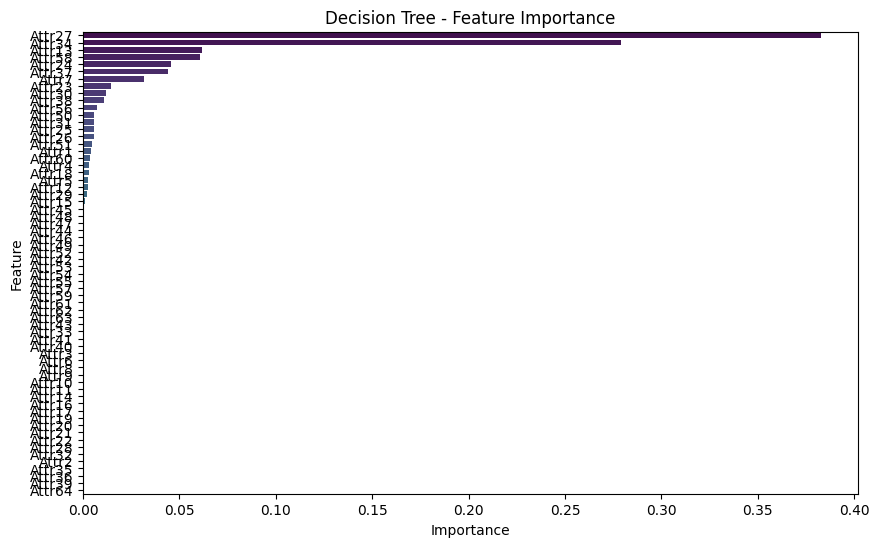


Random Forest Feature Importance:
   Feature  Importance
26  Attr27    0.213845
23  Attr24    0.103212
5    Attr6    0.074492
50  Attr51    0.039768
33  Attr34    0.036706
..     ...         ...
3    Attr4    0.003626
53  Attr54    0.003493
42  Attr43    0.003197
2    Attr3    0.003123
20  Attr21    0.003105

[64 rows x 2 columns]


<ipython-input-97-496d72464b35>:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=feature_importance_df, palette="viridis")


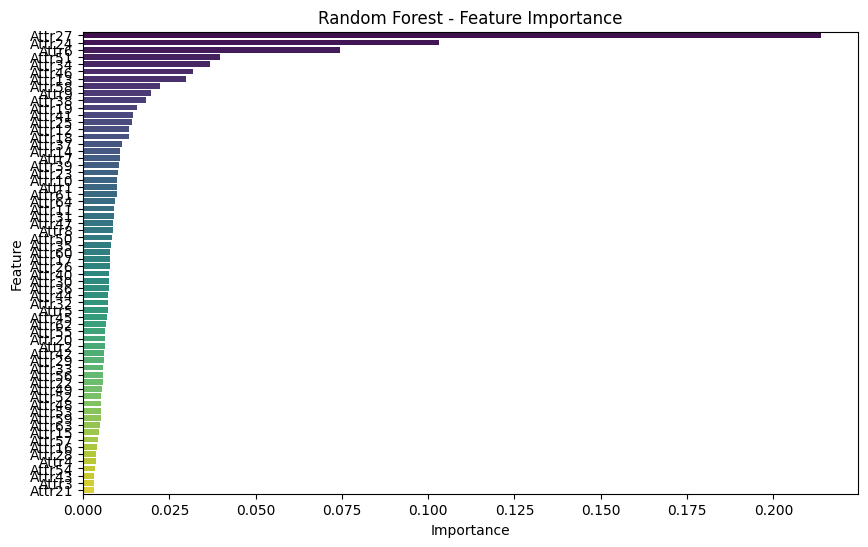


Gradient Boosting Feature Importance:
   Feature  Importance
26  Attr27    0.140350
5    Attr6    0.097760
33  Attr34    0.077197
6    Attr7    0.038468
17  Attr18    0.037491
..     ...         ...
61  Attr62    0.001032
48  Attr49    0.000896
53  Attr54    0.000841
2    Attr3    0.000587
51  Attr52    0.000000

[64 rows x 2 columns]


<ipython-input-97-496d72464b35>:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=feature_importance_df, palette="viridis")


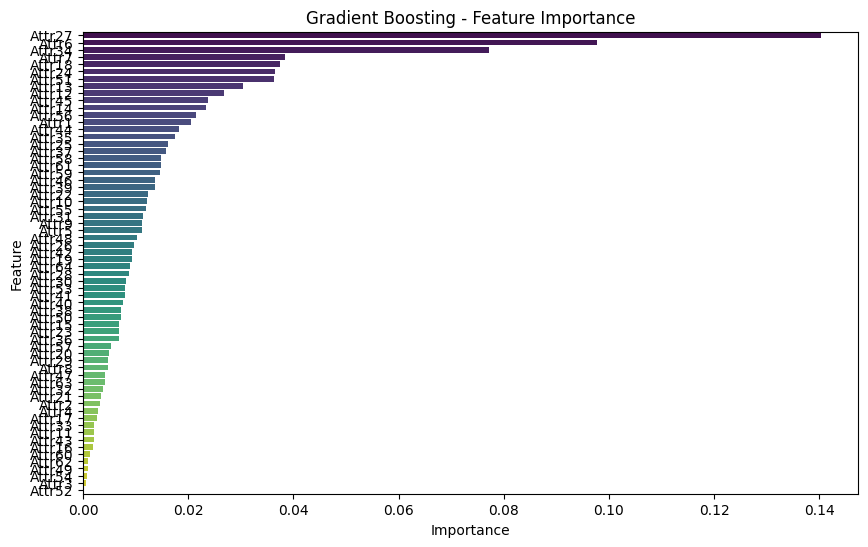

In [97]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Function to display and plot feature importance
def display_and_plot_feature_importance(model, model_name):
    # Get feature importances
    feature_importance = model.feature_importances_

    # Create a DataFrame with feature names and their importance
    feature_importance_df = pd.DataFrame({
        'Feature': X.columns,
        'Importance': feature_importance
    }).sort_values(by='Importance', ascending=False)

    # Display the feature importance
    print(f"\n{model_name} Feature Importance:")
    print(feature_importance_df)

    # Plot the feature importance
    plt.figure(figsize=(10, 6))
    sns.barplot(x='Importance', y='Feature', data=feature_importance_df, palette="viridis")
    plt.title(f"{model_name} - Feature Importance")
    plt.xlabel("Importance")
    plt.ylabel("Feature")
    plt.show()

# Evaluate and plot feature importance for Decision Tree
display_and_plot_feature_importance(dt_final, "Decision Tree")

# Evaluate and plot feature importance for Random Forest
display_and_plot_feature_importance(rf_final, "Random Forest")

# Evaluate and plot feature importance for Gradient Boosting
display_and_plot_feature_importance(xgb_final, "Gradient Boosting")

# **Compare the Performance of Different Models**

<Figure size 1200x600 with 0 Axes>

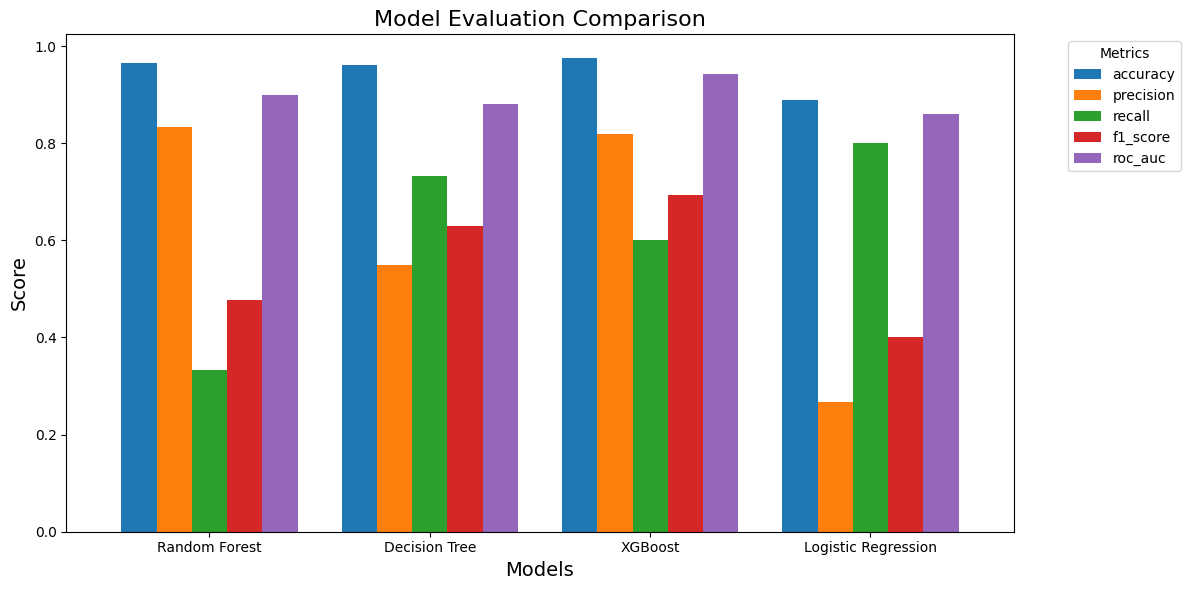

In [127]:
import pandas as pd
import matplotlib.pyplot as plt


# Convert retrained_results dictionary to DataFrame
evaluation_results_df = pd.DataFrame(evaluation_results).T  # Transpose to get models as rows

# Plotting the bar charts for each metric
metrics = ['accuracy', 'precision', 'recall', 'f1_score', 'roc_auc']

# Set the figure size for better readability
plt.figure(figsize=(12, 6))

# Plot the bar chart for all metrics
evaluation_results_df[metrics].plot(kind='bar', figsize=(12, 6), width=0.8)

# Adding labels and title
plt.title('Model Evaluation Comparison', fontsize=16)
plt.ylabel('Score', fontsize=14)
plt.xlabel('Models', fontsize=14)
plt.xticks(rotation=0)  # Make model names readable
plt.legend(title='Metrics', bbox_to_anchor=(1.05, 1), loc='upper left')

# Adjust layout to avoid clipping
plt.tight_layout()

# Show the plot
plt.show()
